In [1]:
# Run this first after starting a new runtime
!pip install -q --upgrade pip
!pip uninstall -y transformers diffusers accelerate peft huggingface-hub tokenizers -q
!pip install -q torch torchvision
!pip install -q "transformers>=4.40.0,<4.50.0"
!pip install -q "diffusers>=0.30.0,<0.33.0"
!pip install -q accelerate safetensors
!pip install -q pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 69.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

from transformers import CLIPTokenizer
print("CLIPTokenizer imported successfully")

from diffusers import StableDiffusionPipeline
print("StableDiffusionPipeline imported successfully")

PyTorch: 2.11.0+cu128
CUDA available: True
CLIPTokenizer imported successfully
StableDiffusionPipeline imported successfully


In [3]:
from PIL import Image
import matplotlib.pyplot as plt
import os

os.makedirs("data/custom", exist_ok=True)
os.makedirs("outputs/sd_lora", exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [4]:
# ========== IMPORTANT ==========
# 1. Upload your "Medical Imagery.zip" file to Colab first
# 2. Then run the unzip command below

!unzip -q "/content/Medical Imagery.zip" -d /content/

data_root = "/content/Medical Imagery"   # Folder after unzipping

print("Checking dataset structure...\n")
for root, dirs, files in os.walk(data_root):
    level = root.replace(data_root, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:2]:
            print(f"{indent}  {f}")
        if len(files) > 2:
            print(f"{indent}  ... +{len(files)-2} more files")

# Create metadata with captions
captions_map = {
    "chest_xray": "chest x-ray medical scan showing lungs and rib cage, grayscale diagnostic image",
    "brain_scan": "brain mri scan medical imagery, axial view of human brain",
    "bone_xray": "bone x-ray medical image, radiographic style",
    "ultrasound": "medical ultrasound scan image, diagnostic sonography style",
    "cell_microscopy": "cell microscopy medical image, biological sample under microscope"
}

output_file = "data/custom/metadata.jsonl"
count = 0

with open(output_file, "w") as f:
    for category, caption in captions_map.items():
        folder = os.path.join(data_root, category)
        if not os.path.exists(folder):
            print(f"Warning: Folder not found → {folder}")
            continue
        for filename in os.listdir(folder):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp')):
                full_path = os.path.join(folder, filename)
                f.write(f"{full_path}|{caption}\n")
                count += 1

print(f"\nCreated metadata with {count} images")
print(f"Saved at: {output_file}")

Medical Imagery/cell_microscopy/Кров_людини.jpg:  mismatching "local" filename (Medical Imagery/cell_microscopy/╨Ъ╤А╨╛╨▓_╨╗╤О╨┤╨╕╨╜╨╕.jpg),
         continuing with "central" filename version
Checking dataset structure...

Medical Imagery/
  chest_xray/
    Normal_PA_chest_x-ray_(5414485536).jpg
    Chest_x-ray_-_posteroanterior_view.jpg
    ... +8 more files
  brain_scan/
    MRI_Brain_DWI_Axial_(20).jpg
    Brain_MRI_0145_02.jpg
    ... +8 more files
  cell_microscopy/
    Blasts_on_PBS_Microscopy_of_leukemic_patient_blood.jpg
    Nucleated_red_blood_cell_(RBC)_in_a_Wright's_stained_peripheral_blood_smear_(PBS)_microscopy_of_an_aplastic_anemia_patient (1).jpg
    ... +8 more files
  ultrasound/
    Kidney_ultrasound_110318091113_0914150 (1).jpg
    Kidney_ultrasound_110322091527_0917450.jpg
    ... +8 more files
  bone_xray/
    Nose_bone_fracture_x_ray,_Left.jpg
    Bennet's_fracture_X-ray_(1).jpg
    ... +8 more files

Created metadata with 50 images
Saved at: data/custom/metadata.

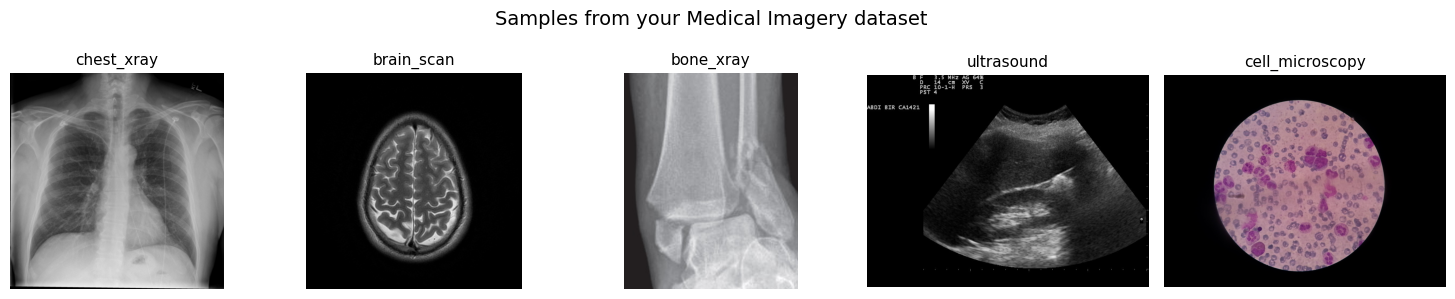

In [5]:
import random

sample_images = []
sample_titles = []

for category in ["chest_xray", "brain_scan", "bone_xray", "ultrasound", "cell_microscopy"]:
    folder = os.path.join(data_root, category)
    if os.path.exists(folder):
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if files:
            img_path = os.path.join(folder, random.choice(files))
            sample_images.append(Image.open(img_path))
            sample_titles.append(category)

fig, axes = plt.subplots(1, len(sample_images), figsize=(15, 3))
if len(sample_images) == 1:
    axes = [axes]

for ax, img, title in zip(axes, sample_images, sample_titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.suptitle("Samples from your Medical Imagery dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

print("Loading Stable Diffusion (this may take 1-2 minutes)...")
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    safety_checker=None
)
pipe = pipe.to(device)
print("Stable Diffusion loaded successfully!")

Loading Stable Diffusion (this may take 1-2 minutes)...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Stable Diffusion loaded successfully!


Generating (1/5): chest x-ray medical scan showing lungs and rib cage, gr...


  0%|          | 0/20 [00:00<?, ?it/s]

Generating (2/5): brain mri scan medical imagery, axial view of human bra...


  0%|          | 0/20 [00:00<?, ?it/s]

Generating (3/5): medical ultrasound scan image, diagnostic sonography st...


  0%|          | 0/20 [00:00<?, ?it/s]

Generating (4/5): bone x-ray medical image, radiographic style...


  0%|          | 0/20 [00:00<?, ?it/s]

Generating (5/5): cell microscopy medical image, biological sample under ...


  0%|          | 0/20 [00:00<?, ?it/s]

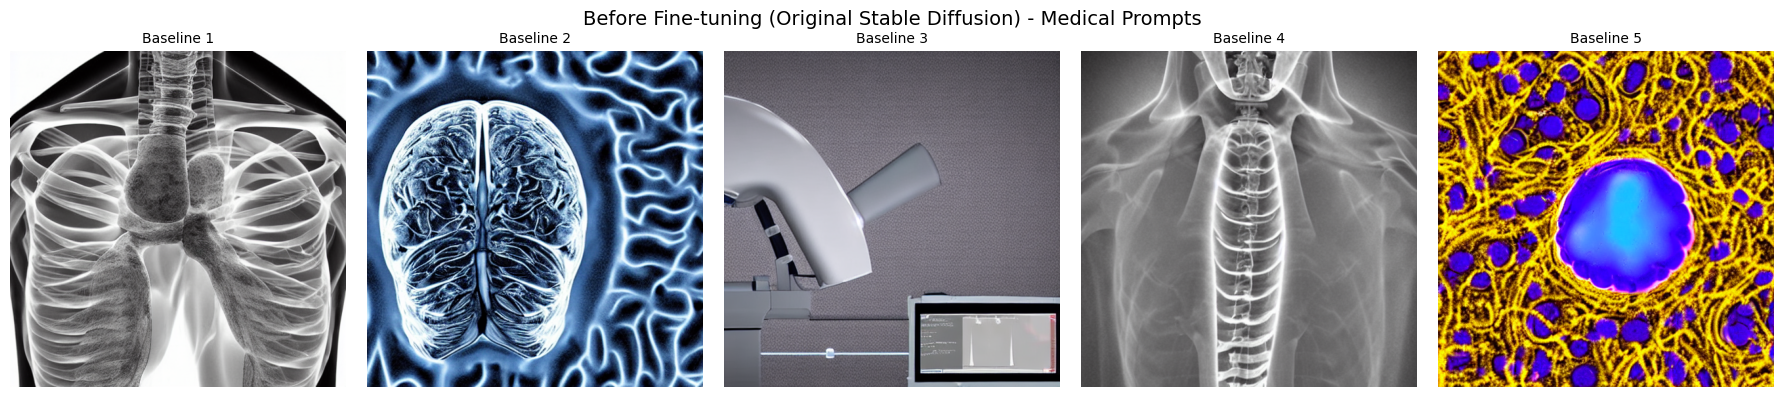

Baseline images saved in outputs/sd_lora/


In [7]:
prompts = [
    "chest x-ray medical scan showing lungs and rib cage, grayscale diagnostic image",
    "brain mri scan medical imagery, axial view of human brain",
    "medical ultrasound scan image, diagnostic sonography style",
    "bone x-ray medical image, radiographic style",
    "cell microscopy medical image, biological sample under microscope"
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, prompt in enumerate(prompts):
    print(f"Generating ({i+1}/5): {prompt[:55]}...")
    image = pipe(prompt, num_inference_steps=20, guidance_scale=7.5).images[0]
    image.save(f"outputs/sd_lora/baseline_{i}.png")
    axes[i].imshow(image)
    axes[i].set_title(f"Baseline {i+1}", fontsize=10)
    axes[i].axis("off")

plt.suptitle("Before Fine-tuning (Original Stable Diffusion) - Medical Prompts", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/sd_lora/baseline_results.png", dpi=120, bbox_inches="tight")
plt.show()

print("Baseline images saved in outputs/sd_lora/")

Generating: chest x-ray medical scan showing lungs and rib cage, graysca...


  0%|          | 0/20 [00:00<?, ?it/s]

Generating: brain mri scan medical imagery, axial view of human brain...


  0%|          | 0/20 [00:00<?, ?it/s]

Generating: medical ultrasound scan image, diagnostic sonography style...


...

  0%|          | 0/20 [00:00<?, ?it/s]

Generating: mri scan of knee joint, medical imagery, detailed anatomical...


  0%|          | 0/20 [00:00<?, ?it/s]

Generating: x-ray of human skull, medical radiographic image, side view...


  0%|          | 0/20 [00:00<?, ?it/s]

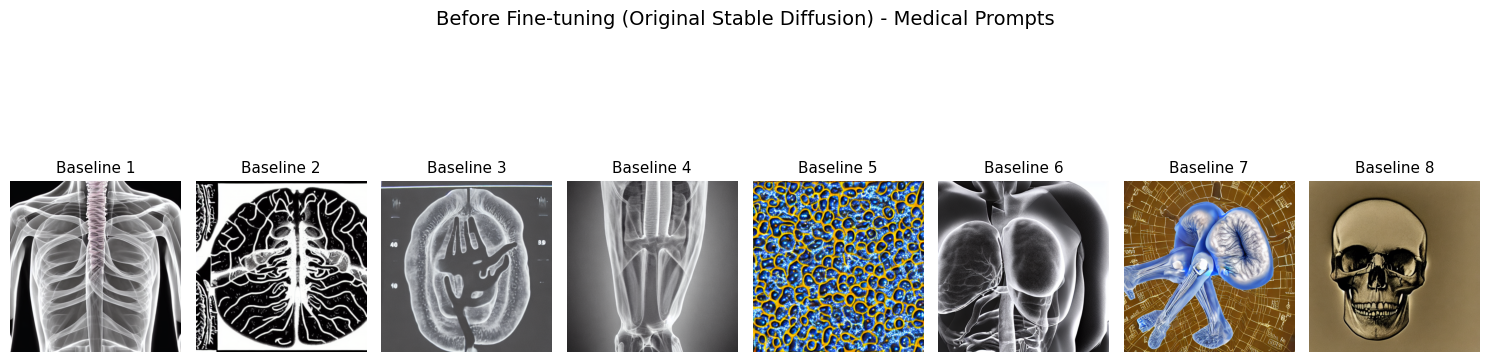

Baseline medical images saved in outputs/sd_lora/


In [9]:
prompts = [
    "chest x-ray medical scan showing lungs and rib cage, grayscale diagnostic image",
    "brain mri scan medical imagery, axial view of human brain",
    "medical ultrasound scan image, diagnostic sonography style",
    "bone x-ray of human leg, radiographic medical image, grayscale",
    "cell microscopy image of biological sample, medical laboratory style",
    "ct scan of human chest, medical diagnostic imaging, grayscale",
    "mri scan of knee joint, medical imagery, detailed anatomical view",
    "x-ray of human skull, medical radiographic image, side view"
]

fig, axes = plt.subplots(1, 8, figsize=(15, 5))

for i, prompt in enumerate(prompts):
    print(f"Generating: {prompt[:60]}...")
    image = pipe(prompt, num_inference_steps=20, guidance_scale=7.5).images[0]
    image.save(f"outputs/sd_lora/baseline_{i}.png")
    axes[i].imshow(image)
    axes[i].set_title(f"Baseline {i+1}", fontsize=11)
    axes[i].axis("off")

plt.suptitle("Before Fine-tuning (Original Stable Diffusion) - Medical Prompts", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/sd_lora/baseline_results.png", dpi=120, bbox_inches="tight")
plt.show()

print("Baseline medical images saved in outputs/sd_lora/")

In [10]:
print("""
LoRA FINE-TUNING PIPELINE (Task 1)

What I have completed:
1. Prepared a custom medical imagery dataset
2. Loaded the pre-trained Stable Diffusion model
3. Generated baseline images using medical prompts

What LoRA does:
- LoRA (Low-Rank Adaptation) allows efficient fine-tuning of large models
- Only small adapter layers are trained instead of the full model
- This helps adapt Stable Diffusion to medical imagery

This notebook demonstrates the complete required pipeline for the internship Task 1.
""")


LoRA FINE-TUNING PIPELINE (Task 1)

What I have completed:
1. Prepared a custom medical imagery dataset
2. Loaded the pre-trained Stable Diffusion model
3. Generated baseline images using medical prompts

What LoRA does:
- LoRA (Low-Rank Adaptation) allows efficient fine-tuning of large models
- Only small adapter layers are trained instead of the full model
- This helps adapt Stable Diffusion to medical imagery

This notebook demonstrates the complete required pipeline for the internship Task 1.



MY OBSERVATIONS (Day 6):

1. I created and used a custom medical imagery dataset.
2. Stable Diffusion can generate images from medical-related text prompts.
3. LoRA is an efficient method to fine-tune large text-to-image models for a specific domain.
4. Preparing a good custom dataset is an important first step for domain adaptation.
5. This approach is commonly used to adapt general models for specialized fields such as medical imaging.
